In [1]:
import sys, os
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('data/graficas', exist_ok=True)

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.")

2026-05-13 16:14:45.708 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas   2.2.3
   numpy    1.26.4
   seaborn  0.13.2

⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.


In [2]:
# Clasificamos un anime como "top_tier" si su score >= 8.5
# (aprox. el percentil 75% de nuestro dataset)
SQL_QUERY = """
SELECT
    score,
    popularity,
    favorites,
    episodes,
    rank,
    CASE
        WHEN score >= 8.5 THEN 1
        ELSE 0
    END AS es_top_tier
FROM anime
WHERE score      IS NOT NULL
  AND popularity IS NOT NULL
  AND favorites  IS NOT NULL
  AND episodes   IS NOT NULL
  AND rank       IS NOT NULL
ORDER BY rank
"""

with engine.connect() as conn:
    df = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df['es_top_tier'].value_counts()
pct = df['es_top_tier'].value_counts(normalize=True) * 100
print(f"   Top Tier (score ≥ 8.5) [1]: {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Resto   (score < 8.5) [0]: {bal[0]:,}  ({pct[0]:.1f}%)")
df.head()

✅ Datos cargados: 485 filas × 6 columnas

Columnas disponibles:
['score', 'popularity', 'favorites', 'episodes', 'rank', 'es_top_tier']

Balance de la variable objetivo:
   Top Tier (score ≥ 8.5) [1]: 164  (33.8%)
   Resto   (score < 8.5) [0]: 321  (66.2%)


,score,popularity,favorites,episodes,rank,es_top_tier
0,9.28,108,85781,28,1,1
1,9.16,650,5418,10,2,1
2,9.11,3,240854,64,3,1
3,9.09,647,12022,1,4,1
4,9.07,14,201123,24,5,1


VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
               dtype  nulos
score        float64      0
popularity     int64      0
favorites      int64      0
episodes       int64      0
rank           int64      0
es_top_tier    int64      0

📊 Estadísticas por clase:
             score  favorites  popularity  episodes
es_top_tier                                        
0             8.30    8653.18     1690.25     18.98
1             8.69   23513.21     1013.09     17.80


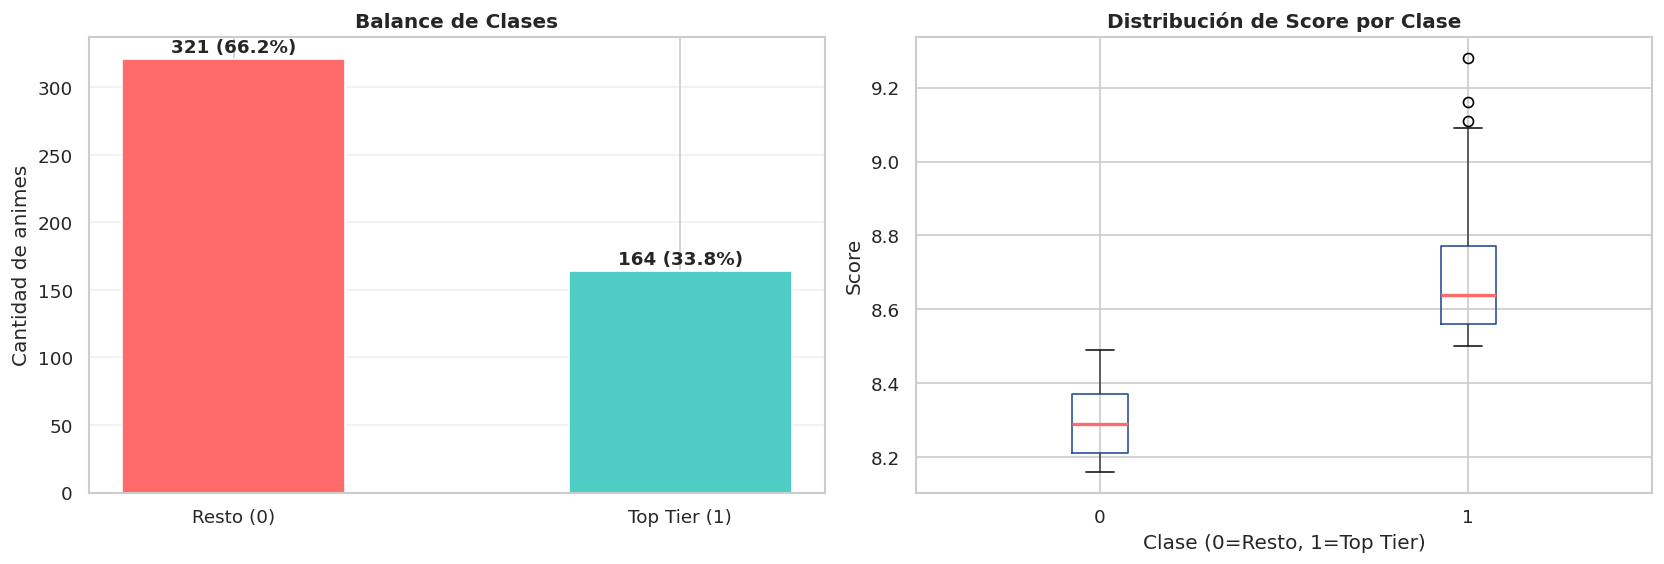

In [3]:
print("="*55)
print("VALIDACIÓN DEL DATASET")
print("="*55)
print(f"\n📋 Tipos de datos y valores nulos:")
info = pd.DataFrame({'dtype': df.dtypes, 'nulos': df.isnull().sum()})
print(info.to_string())

print(f"\n📊 Estadísticas por clase:")
print(df.groupby('es_top_tier')[['score', 'favorites', 'popularity', 'episodes']].mean().round(2))

# Gráfica de balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Exploración del Dataset — Clasificación Top Tier Anime', fontweight='bold')

# Balance de clases
clases = ['Resto (0)', 'Top Tier (1)']
conteos = [bal[0], bal[1]]
colores = ['#ff6b6b', '#4ecdc4']
axes[0].bar(clases, conteos, color=colores, edgecolor='white', width=0.5)
axes[0].set_title('Balance de Clases', fontweight='bold')
axes[0].set_ylabel('Cantidad de animes')
for i, v in enumerate(conteos):
    axes[0].text(i, v + 5, f'{v} ({pct[i]:.1f}%)', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Distribución de score por clase
df.boxplot(column='score', by='es_top_tier', ax=axes[1],
           boxprops=dict(color='#2a5298'), medianprops=dict(color='#ff6b6b', lw=2))
axes[1].set_title('Distribución de Score por Clase', fontweight='bold')
axes[1].set_xlabel('Clase (0=Resto, 1=Top Tier)')
axes[1].set_ylabel('Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig('data/graficas/cart_cls_exploracion.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
FEATURES = ['popularity', 'favorites', 'episodes', 'rank']

X_raw = df[FEATURES].values
y     = df['es_top_tier'].values

print(f"Features: {FEATURES}")
print(f"X shape : {X_raw.shape}")
print(f"y shape : {y.shape}")
print(f"Clases  : {np.unique(y)} (0=Resto, 1=Top Tier)")

resultados_globales = []

def evaluar_split_cls(X, y, test_size, split_label, resultados_globales):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    modelo = DecisionTreeClassifier(random_state=42)
    modelo.fit(X_train, y_train)
    y_pred      = modelo.predict(X_test)
    y_pred_prob = modelo.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    pct_train = int((1 - test_size) * 100)
    pct_test  = int(test_size * 100)

    print(f"\n{'='*60}")
    print(f"  {split_label} — {pct_train}% Train / {pct_test}% Test")
    print(f"{'='*60}")
    print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}")
    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  — de los que predice Top Tier, {prec*100:.1f}% lo son realmente")
    print(f"  Recall    : {rec:.4f}  — detecta el {rec*100:.1f}% de los Top Tier reales")
    print(f"  F1-Score  : {f1:.4f}  — balance Precision/Recall")
    print(f"  ROC-AUC   : {auc:.4f}  — capacidad discriminativa del modelo")

    resultados_globales.append({
        'Split': split_label, 'Train': len(X_train), 'Test': len(X_test),
        'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1': round(f1, 4), 'AUC': round(auc, 4)
    })

    # ── Gráficas: Matriz de confusión + Curva ROC ──────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Árbol de Decisión Clasificación — {split_label}',
                 fontsize=13, fontweight='bold')

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Resto (0)', 'Top Tier (1)'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de Confusión\nAcc={acc:.4f}', fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    axes[1].plot(fpr, tpr, color='#2a5298', lw=2, label=f'ROC (AUC={auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aleatorio')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2a5298')
    axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f"data/graficas/cart_cls_{split_label.replace(' ', '_').replace('/', '-')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred, y_pred_prob

Features: ['popularity', 'favorites', 'episodes', 'rank']
X shape : (485, 4)
y shape : (485,)
Clases  : [0 1] (0=Resto, 1=Top Tier)



  Split 1 (80/20) — 80% Train / 20% Test
  Train: 388  |  Test: 97

  📊 MÉTRICAS (Split 1 (80/20))
  ──────────────────────────────────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000  — de los que predice Top Tier, 100.0% lo son realmente
  Recall    : 1.0000  — detecta el 100.0% de los Top Tier reales
  F1-Score  : 1.0000  — balance Precision/Recall
  ROC-AUC   : 1.0000  — capacidad discriminativa del modelo


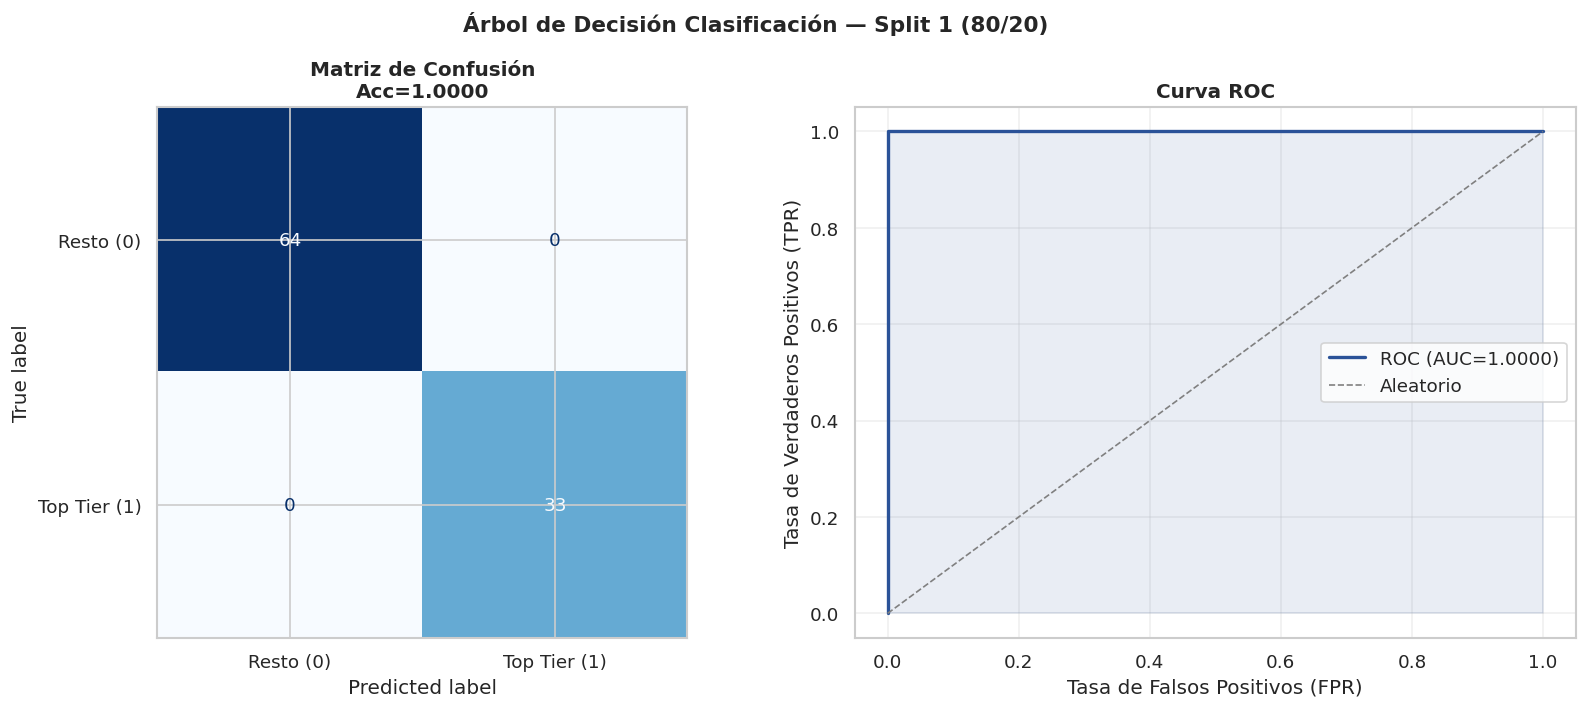

  💾 Gráfico guardado → data/graficas/cart_cls_Split_1_(80-20).png


In [5]:
modelo_s1, y_test_s1, y_pred_s1, y_prob_s1 = evaluar_split_cls(
    X_raw, y, test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


  Split 2 (60/40) — 60% Train / 40% Test
  Train: 291  |  Test: 194

  📊 MÉTRICAS (Split 2 (60/40))
  ──────────────────────────────────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000  — de los que predice Top Tier, 100.0% lo son realmente
  Recall    : 1.0000  — detecta el 100.0% de los Top Tier reales
  F1-Score  : 1.0000  — balance Precision/Recall
  ROC-AUC   : 1.0000  — capacidad discriminativa del modelo


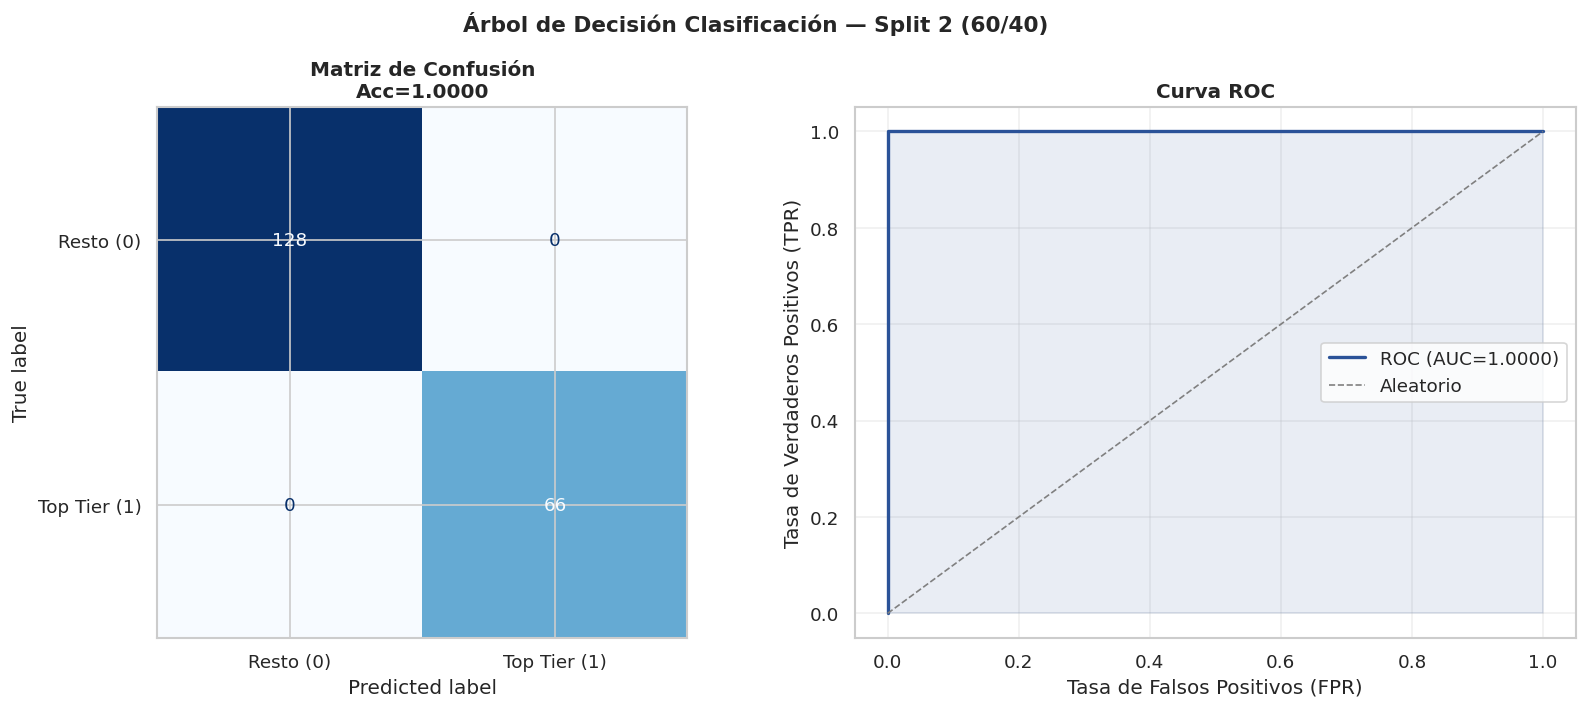

  💾 Gráfico guardado → data/graficas/cart_cls_Split_2_(60-40).png


In [6]:
modelo_s2, y_test_s2, y_pred_s2, y_prob_s2 = evaluar_split_cls(
    X_raw, y, test_size=0.40,
    split_label='Split 2 (60/40)',
    resultados_globales=resultados_globales,
)


  Split 3 (70/30) — 70% Train / 30% Test
  Train: 339  |  Test: 146

  📊 MÉTRICAS (Split 3 (70/30))
  ──────────────────────────────────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000  — de los que predice Top Tier, 100.0% lo son realmente
  Recall    : 1.0000  — detecta el 100.0% de los Top Tier reales
  F1-Score  : 1.0000  — balance Precision/Recall
  ROC-AUC   : 1.0000  — capacidad discriminativa del modelo


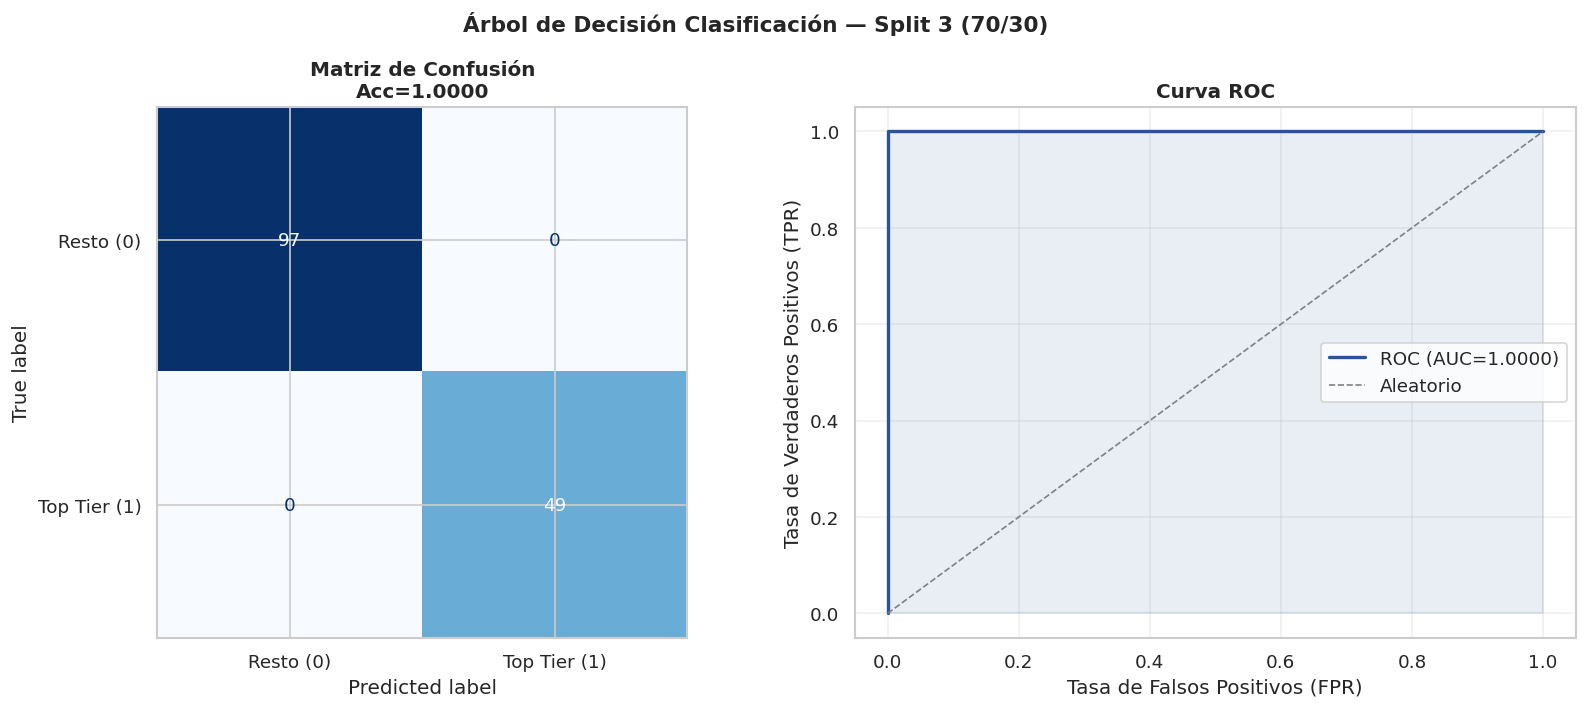

  💾 Gráfico guardado → data/graficas/cart_cls_Split_3_(70-30).png


In [7]:
modelo_s3, y_test_s3, y_pred_s3, y_prob_s3 = evaluar_split_cls(
    X_raw, y, test_size=0.30,
    split_label='Split 3 (70/30)',
    resultados_globales=resultados_globales,
)

📊 IMPORTANCIA DE VARIABLES (Split 1 — 80/20)
   Feature  Importancia
      rank          1.0
popularity          0.0
 favorites          0.0
  episodes          0.0


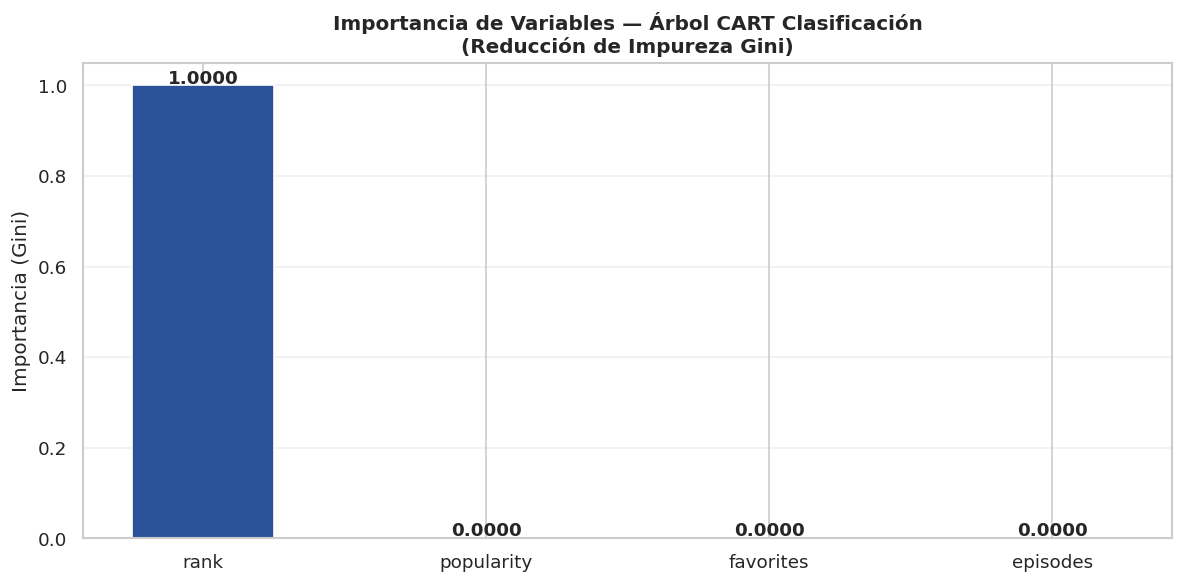

In [8]:
importancias = pd.DataFrame({
    'Feature'    : FEATURES,
    'Importancia': modelo_s1.feature_importances_
}).sort_values('Importancia', ascending=False)

print("📊 IMPORTANCIA DE VARIABLES (Split 1 — 80/20)")
print("="*45)
print(importancias.to_string(index=False))
print("="*45)

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#2a5298', '#4ecdc4', '#f7b731', '#ff6b6b']
bars = ax.bar(importancias['Feature'], importancias['Importancia'],
              color=colores[:len(FEATURES)], edgecolor='white', width=0.5)
ax.set_title('Importancia de Variables — Árbol CART Clasificación\n(Reducción de Impureza Gini)',
             fontweight='bold')
ax.set_ylabel('Importancia (Gini)')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, importancias['Importancia']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/graficas/cart_cls_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

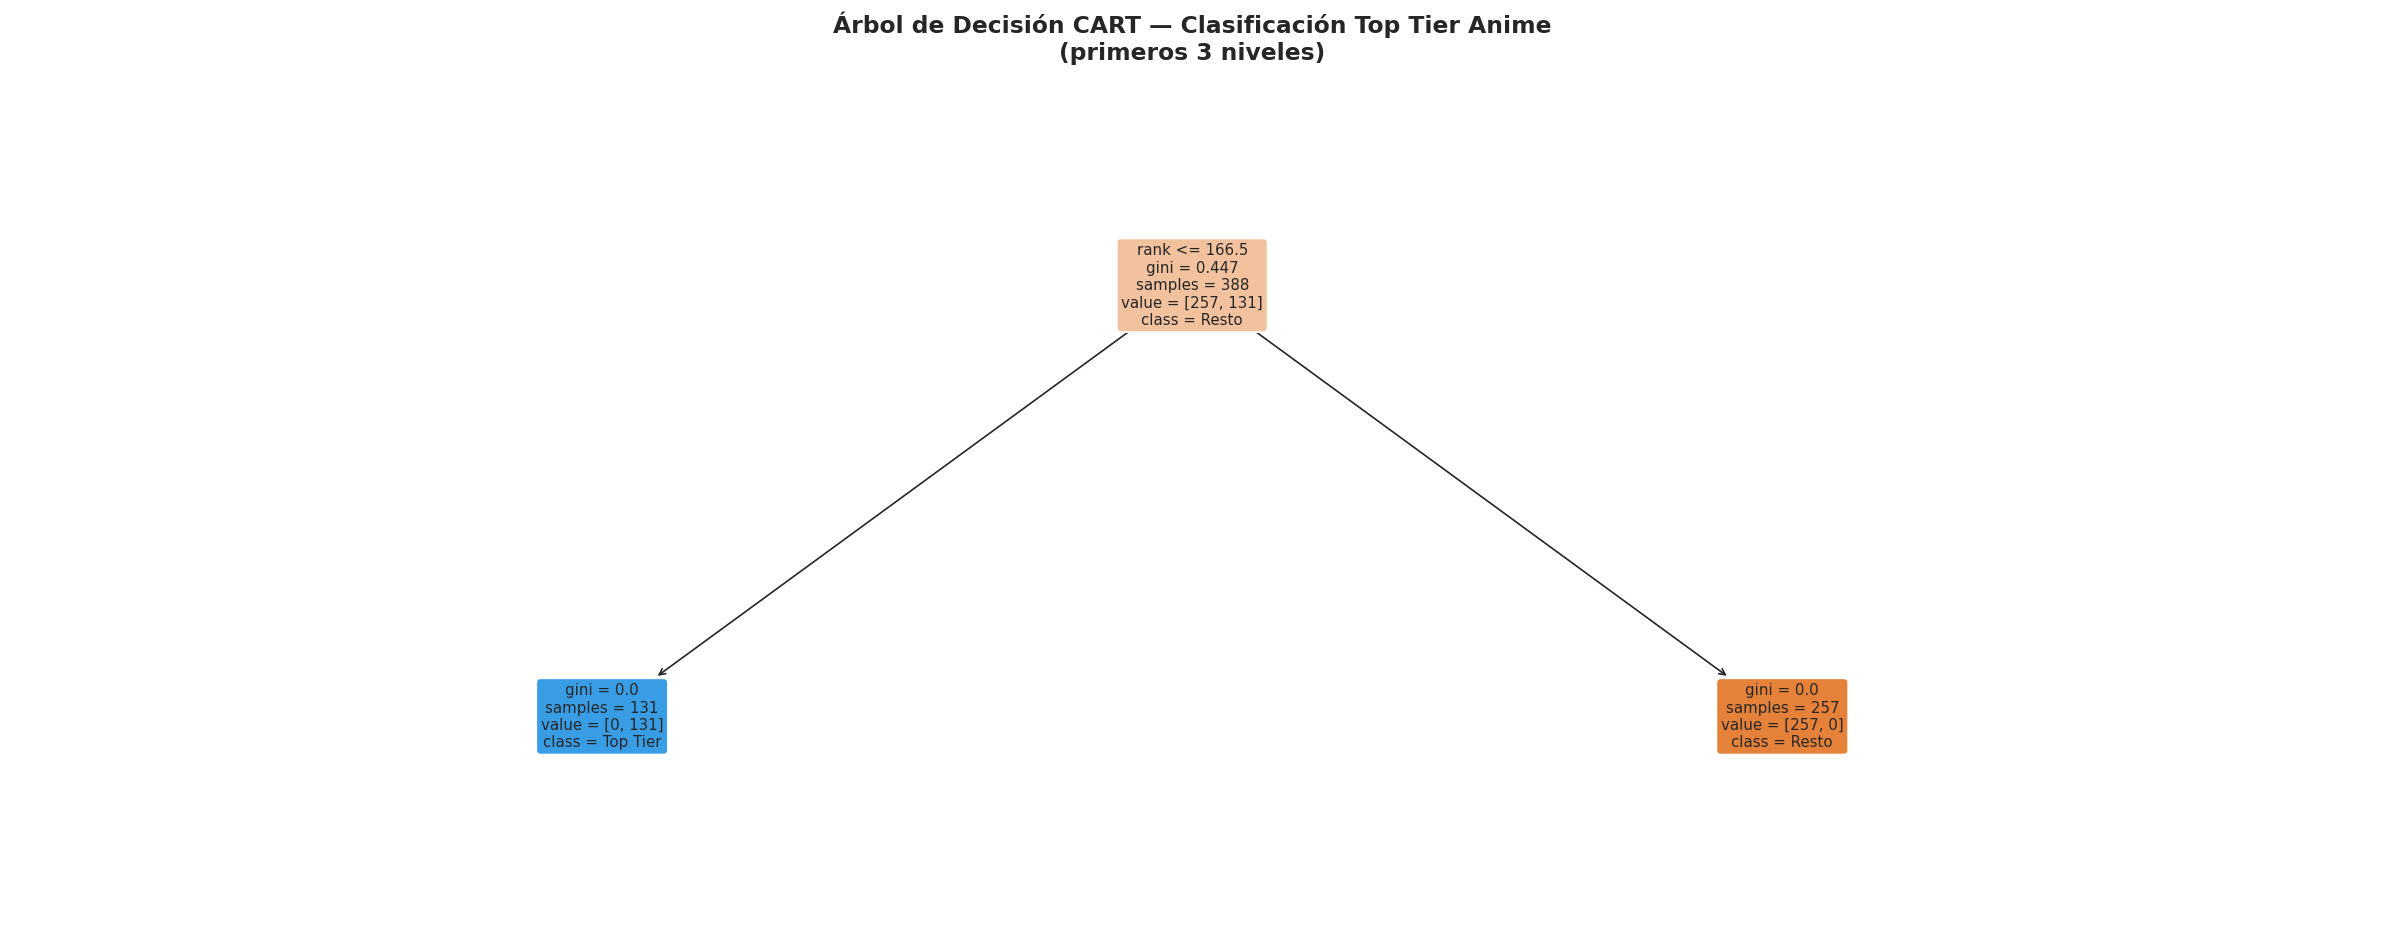

💾 Guardado: data/graficas/cart_cls_arbol.png


In [9]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    modelo_s1, max_depth=3,
    feature_names=FEATURES,
    class_names=['Resto', 'Top Tier'],
    filled=True, rounded=True,
    fontsize=9, ax=ax
)
ax.set_title('Árbol de Decisión CART — Clasificación Top Tier Anime\n(primeros 3 niveles)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/graficas/cart_cls_arbol.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/cart_cls_arbol.png")


  TABLA COMPARATIVA — ÁRBOL CART CLASIFICACIÓN (Top Tier Anime)
          Split  Train  Test  Accuracy  Precision  Recall  F1  AUC
Split 1 (80/20)    388    97       1.0        1.0     1.0 1.0  1.0
Split 2 (60/40)    291   194       1.0        1.0     1.0 1.0  1.0
Split 3 (70/30)    339   146       1.0        1.0     1.0 1.0  1.0


/tmp/ipykernel_384/411757508.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_384/411757508.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_384/411757508.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_384/411757508.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_384/411757508.py:20: UserWarning: set_ticklabels() should onl

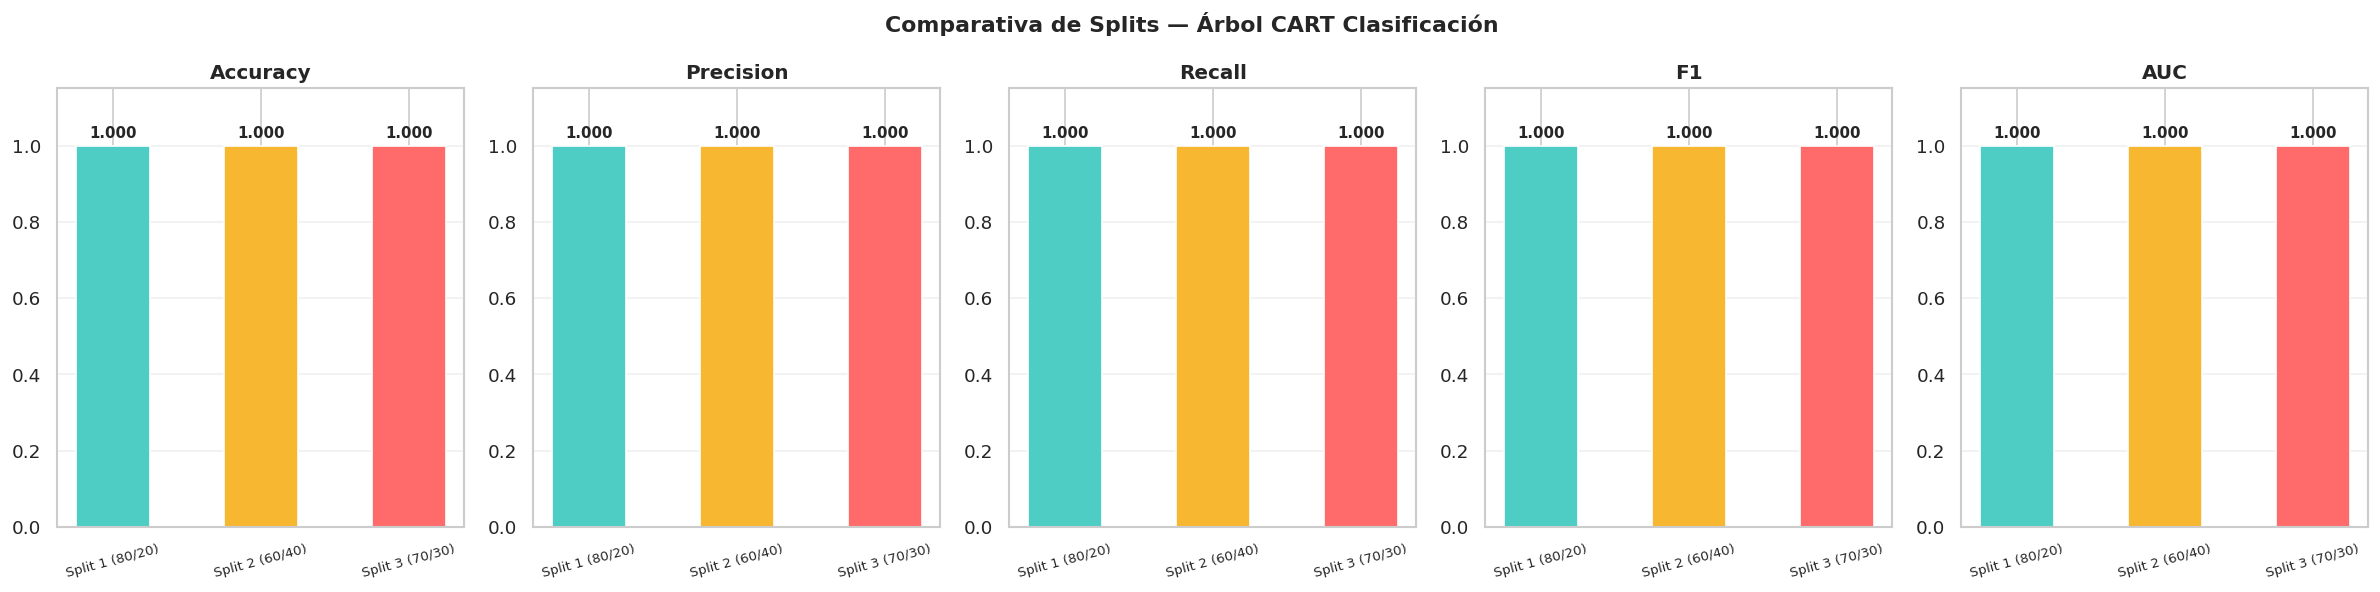


1. ESTABILIDAD DEL MODELO
   Rango Accuracy entre splits: 0.0000
   ✅ Modelo estable — no depende críticamente del tamaño del split

2. MEJOR SPLIT (por F1-Score)
   Split 1 (80/20)  →  F1=1.0000, AUC=1.0000

3. RECOMENDACIÓN
   A) Regularizar: DecisionTreeClassifier(max_depth=5, min_samples_leaf=15)
   B) Buscar umbral óptimo con la curva ROC (no siempre 0.5 es lo mejor)
   C) Considerar class_weight='balanced' si el desbalance afecta el Recall
   D) Comparar con RandomForestClassifier para mayor robustez



In [10]:
df_resumen = pd.DataFrame(resultados_globales)

print("\n" + "="*75)
print("  TABLA COMPARATIVA — ÁRBOL CART CLASIFICACIÓN (Top Tier Anime)")
print("="*75)
print(df_resumen.to_string(index=False))
print("="*75)

# Gráfica comparativa
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
fig, axes = plt.subplots(1, len(metricas), figsize=(20, 5))
fig.suptitle('Comparativa de Splits — Árbol CART Clasificación', fontweight='bold')

colores_splits = ['#4ecdc4', '#f7b731', '#ff6b6b']
for ax, met in zip(axes, metricas):
    vals = df_resumen[met].values
    ax.bar(df_resumen['Split'], vals, color=colores_splits, edgecolor='white', width=0.5)
    ax.set_title(met, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/cart_cls_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis
acc_rango = df_resumen['Accuracy'].max() - df_resumen['Accuracy'].min()
best = df_resumen.loc[df_resumen['F1'].idxmax()]

print(f"\n1. ESTABILIDAD DEL MODELO")
print(f"   Rango Accuracy entre splits: {acc_rango:.4f}")
if acc_rango < 0.05:
    print("   ✅ Modelo estable — no depende críticamente del tamaño del split")
else:
    print("   ⚠️  Variación notable — posible overfitting")

print(f"\n2. MEJOR SPLIT (por F1-Score)")
print(f"   {best['Split']}  →  F1={best['F1']:.4f}, AUC={best['AUC']:.4f}")

print("""
3. RECOMENDACIÓN
   A) Regularizar: DecisionTreeClassifier(max_depth=5, min_samples_leaf=15)
   B) Buscar umbral óptimo con la curva ROC (no siempre 0.5 es lo mejor)
   C) Considerar class_weight='balanced' si el desbalance afecta el Recall
   D) Comparar con RandomForestClassifier para mayor robustez
""")